# HaluEval QA Dataset Exploration

**Purpose:** Inspect the raw HaluEval QA dataset to understand its structure, quality, and characteristics.

**Date:** 2026-09-02

---

In [2]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Dataset

In [3]:
# Path to raw dataset
DATA_PATH = Path('../data/raw/halueval_qa.jsonl')

# Load JSONL file
data_records = []
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        data_records.append(json.loads(line.strip()))

# Convert to DataFrame
df = pd.DataFrame(data_records)

print(f"Total records loaded: {len(df)}")
print(f"\nDataFrame shape: {df.shape}")

Total records loaded: 10000

DataFrame shape: (10000, 4)


## 2. Dataset Structure

In [4]:
print("Column Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nDataset Info:")
df.info()

Column Names:
['knowledge', 'question', 'right_answer', 'hallucinated_answer']

Data Types:
knowledge              object
question               object
right_answer           object
hallucinated_answer    object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   knowledge            10000 non-null  object
 1   question             10000 non-null  object
 2   right_answer         10000 non-null  object
 3   hallucinated_answer  10000 non-null  object
dtypes: object(4)
memory usage: 312.6+ KB


## 3. Sample Records

In [5]:
print("First 3 records:")
print("="*80)
for idx in range(min(3, len(df))):
    print(f"\nRecord {idx+1}:")
    print(f"Knowledge: {df.iloc[idx]['knowledge'][:100]}...")
    print(f"Question: {df.iloc[idx]['question']}")
    print(f"Right Answer: {df.iloc[idx]['right_answer']}")
    print(f"Hallucinated Answer: {df.iloc[idx]['hallucinated_answer']}")
    print("-"*80)

First 3 records:

Record 1:
Knowledge: Arthur's Magazine (1844–1846) was an American literary periodical published in Philadelphia in the 1...
Question: Which magazine was started first Arthur's Magazine or First for Women?
Right Answer: Arthur's Magazine
Hallucinated Answer: First for Women was started first.
--------------------------------------------------------------------------------

Record 2:
Knowledge: The Oberoi family is an Indian family that is famous for its involvement in hotels, namely through T...
Question: The Oberoi family is part of a hotel company that has a head office in what city?
Right Answer: Delhi
Hallucinated Answer: The Oberoi family's hotel company is based in Mumbai.
--------------------------------------------------------------------------------

Record 3:
Knowledge: Allison Beth "Allie" Goertz (born March 2, 1991) is an American musician. Goertz is known for her sa...
Question: Musician and satirist Allie Goertz wrote a song about the "The Simpsons" char

In [6]:
# Display full first record
print("\nComplete First Record:")
print(json.dumps(data_records[0], indent=2))


Complete First Record:
{
  "knowledge": "Arthur's Magazine (1844\u20131846) was an American literary periodical published in Philadelphia in the 19th century.First for Women is a woman's magazine published by Bauer Media Group in the USA.",
  "question": "Which magazine was started first Arthur's Magazine or First for Women?",
  "right_answer": "Arthur's Magazine",
  "hallucinated_answer": "First for Women was started first."
}


## 4. Missing Values Analysis

In [7]:
# Check for None/NaN values
print("Missing Values (None/NaN):")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
})
print(missing_df)

# Check for empty strings
print("\nEmpty Strings:")
for col in df.columns:
    empty_count = (df[col] == '').sum()
    if empty_count > 0:
        print(f"{col}: {empty_count} ({empty_count/len(df)*100:.2f}%)")
    else:
        print(f"{col}: 0 (0.00%)")

Missing Values (None/NaN):
                Column  Missing Count  Missing %
0            knowledge              0        0.0
1             question              0        0.0
2         right_answer              0        0.0
3  hallucinated_answer              0        0.0

Empty Strings:
knowledge: 0 (0.00%)
question: 0 (0.00%)
right_answer: 0 (0.00%)
hallucinated_answer: 0 (0.00%)


## 5. Duplicate Analysis

In [8]:
# Exact duplicate rows
exact_duplicates = df.duplicated().sum()
print(f"Exact duplicate rows: {exact_duplicates}")

# Duplicate questions
duplicate_questions = df['question'].duplicated().sum()
print(f"Duplicate questions: {duplicate_questions}")

# Duplicate question-knowledge pairs
duplicate_pairs = df[['question', 'knowledge']].duplicated().sum()
print(f"Duplicate question-knowledge pairs: {duplicate_pairs}")

# Show some duplicate questions if they exist
if duplicate_questions > 0:
    print("\nSample duplicate questions:")
    dup_q = df[df['question'].duplicated(keep=False)].sort_values('question').head(6)
    print(dup_q[['question', 'right_answer', 'hallucinated_answer']])

Exact duplicate rows: 0
Duplicate questions: 0
Duplicate question-knowledge pairs: 0


## 6. Text Length Statistics

In [9]:
# Calculate character lengths
df['knowledge_len'] = df['knowledge'].apply(len)
df['question_len'] = df['question'].apply(len)
df['right_answer_len'] = df['right_answer'].apply(len)
df['hallucinated_answer_len'] = df['hallucinated_answer'].apply(len)

# Calculate word counts
df['knowledge_words'] = df['knowledge'].apply(lambda x: len(x.split()))
df['question_words'] = df['question'].apply(lambda x: len(x.split()))
df['right_answer_words'] = df['right_answer'].apply(lambda x: len(x.split()))
df['hallucinated_answer_words'] = df['hallucinated_answer'].apply(lambda x: len(x.split()))

print("Text Length Statistics (characters):")
print("="*80)
length_stats = df[['knowledge_len', 'question_len', 'right_answer_len', 'hallucinated_answer_len']].describe()
print(length_stats)

Text Length Statistics (characters):
       knowledge_len  question_len  right_answer_len  hallucinated_answer_len
count   10000.000000  10000.000000      10000.000000             10000.000000
mean      344.268300    106.407600         13.653800                66.224000
std       134.672261     60.532187         12.028309                36.287815
min        75.000000     20.000000          1.000000                 3.000000
25%       247.000000     70.000000          7.000000                40.000000
50%       321.000000     90.000000         12.000000                58.000000
75%       417.000000    121.000000         17.000000                85.000000
max      1557.000000    630.000000        529.000000               380.000000


In [10]:
print("\nText Length Statistics (words):")
print("="*80)
word_stats = df[['knowledge_words', 'question_words', 'right_answer_words', 'hallucinated_answer_words']].describe()
print(word_stats)


Text Length Statistics (words):
       knowledge_words  question_words  right_answer_words  \
count     10000.000000    10000.000000        10000.000000   
mean         55.447400       17.943100            2.224700   
std          21.597395        9.740346            1.844926   
min          11.000000        4.000000            1.000000   
25%          40.000000       12.000000            1.000000   
50%          52.000000       16.000000            2.000000   
75%          67.000000       21.000000            3.000000   
max         256.000000      100.000000           81.000000   

       hallucinated_answer_words  
count               10000.000000  
mean                   10.986500  
std                     6.145787  
min                     1.000000  
25%                     6.000000  
50%                     9.000000  
75%                    14.000000  
max                    61.000000  


## 7. Length Distribution Visualizations

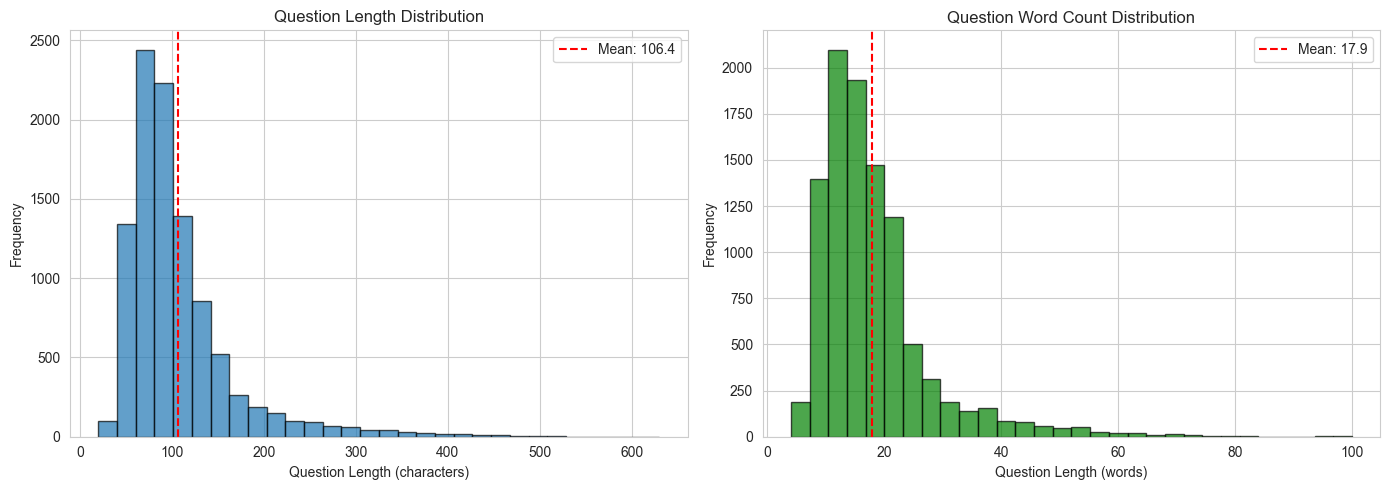

In [11]:
# Question length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['question_len'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Question Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Question Length Distribution')
axes[0].axvline(df['question_len'].mean(), color='red', linestyle='--', label=f"Mean: {df['question_len'].mean():.1f}")
axes[0].legend()

axes[1].hist(df['question_words'], bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Question Length (words)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Question Word Count Distribution')
axes[1].axvline(df['question_words'].mean(), color='red', linestyle='--', label=f"Mean: {df['question_words'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

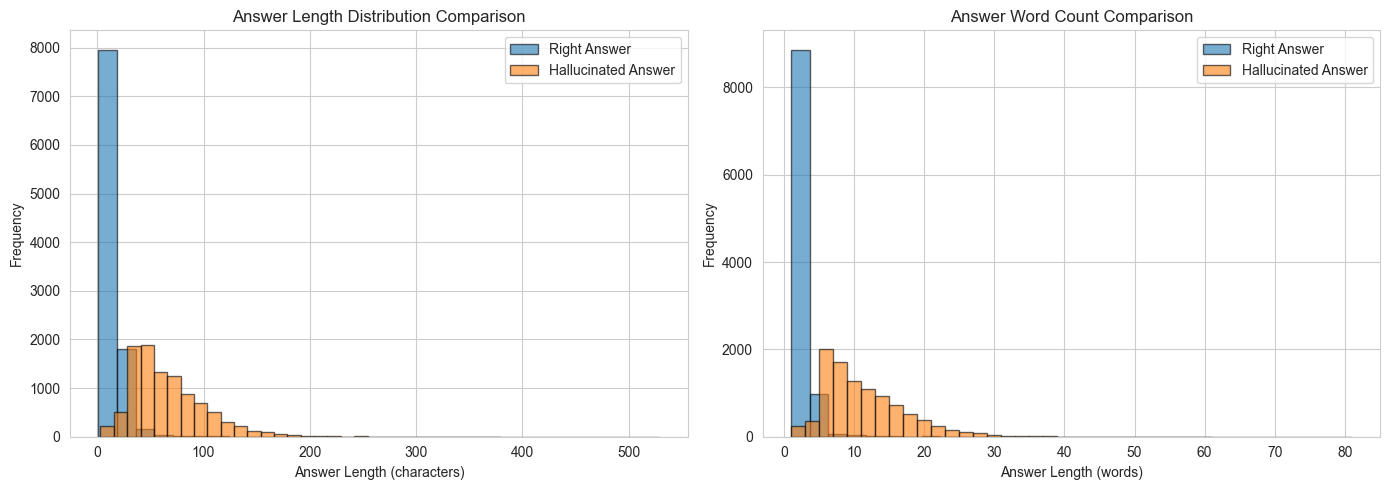


Mean right answer length: 13.65 chars, 2.22 words
Mean hallucinated answer length: 66.22 chars, 10.99 words


In [12]:
# Answer length comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['right_answer_len'], bins=30, alpha=0.6, label='Right Answer', edgecolor='black')
axes[0].hist(df['hallucinated_answer_len'], bins=30, alpha=0.6, label='Hallucinated Answer', edgecolor='black')
axes[0].set_xlabel('Answer Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Answer Length Distribution Comparison')
axes[0].legend()

axes[1].hist(df['right_answer_words'], bins=30, alpha=0.6, label='Right Answer', edgecolor='black')
axes[1].hist(df['hallucinated_answer_words'], bins=30, alpha=0.6, label='Hallucinated Answer', edgecolor='black')
axes[1].set_xlabel('Answer Length (words)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Answer Word Count Comparison')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nMean right answer length: {df['right_answer_len'].mean():.2f} chars, {df['right_answer_words'].mean():.2f} words")
print(f"Mean hallucinated answer length: {df['hallucinated_answer_len'].mean():.2f} chars, {df['hallucinated_answer_words'].mean():.2f} words")

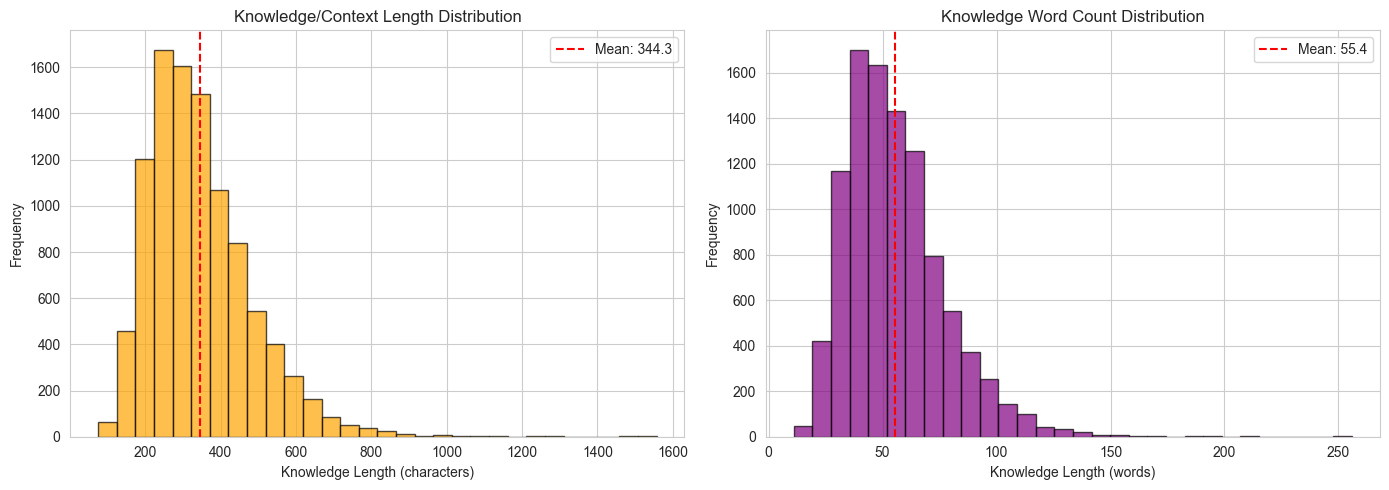

In [13]:
# Knowledge length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['knowledge_len'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[0].set_xlabel('Knowledge Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Knowledge/Context Length Distribution')
axes[0].axvline(df['knowledge_len'].mean(), color='red', linestyle='--', label=f"Mean: {df['knowledge_len'].mean():.1f}")
axes[0].legend()

axes[1].hist(df['knowledge_words'], bins=30, edgecolor='black', alpha=0.7, color='purple')
axes[1].set_xlabel('Knowledge Length (words)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Knowledge Word Count Distribution')
axes[1].axvline(df['knowledge_words'].mean(), color='red', linestyle='--', label=f"Mean: {df['knowledge_words'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Outlier Detection

In [14]:
# Find unusually long/short records
print("Outlier Analysis:")
print("="*80)

print("\nShortest question:")
shortest_q = df.loc[df['question_len'].idxmin()]
print(f"Length: {shortest_q['question_len']} chars")
print(f"Question: {shortest_q['question']}")

print("\nLongest question:")
longest_q = df.loc[df['question_len'].idxmax()]
print(f"Length: {longest_q['question_len']} chars")
print(f"Question: {longest_q['question']}")

print("\nShortest right answer:")
shortest_ra = df.loc[df['right_answer_len'].idxmin()]
print(f"Length: {shortest_ra['right_answer_len']} chars")
print(f"Answer: {shortest_ra['right_answer']}")

print("\nLongest right answer:")
longest_ra = df.loc[df['right_answer_len'].idxmax()]
print(f"Length: {longest_ra['right_answer_len']} chars")
print(f"Answer: {longest_ra['right_answer'][:200]}...")

print("\nLongest hallucinated answer:")
longest_ha = df.loc[df['hallucinated_answer_len'].idxmax()]
print(f"Length: {longest_ha['hallucinated_answer_len']} chars")
print(f"Answer: {longest_ha['hallucinated_answer'][:200]}...")

Outlier Analysis:

Shortest question:
Length: 20 chars
Question: Whose album was Red?

Longest question:
Length: 630 chars
Question: The Black Mafia, also known as the Muslim Mafia, Muslim Mob, Philadelphia Black Mafia, or which acronym, is a Philadelphia-based African-American organized crime syndicate, Black Mafia was also engaged in traditional organized crime activities such as number running, The numbers game, also known as the numbers racket, the policy racket, the Italian lottery, the policy game, or the daily number is a form of illegal gambling or illegal lottery played mostly in poor and working class neighborhoods in the United States, wherein a bettor attempts to pick three digits to match those that will be randomly drawn the following day?

Shortest right answer:
Length: 1 chars
Answer: A

Longest right answer:
Length: 529 chars
Answer: The JKWI was the designated operator of the Irvine, Warren, Kane & Johnsonburg Railroad, that was a partnership of Brock Railroad (a whol

## 9. Character Encoding & Special Characters

In [15]:
# Check for non-ASCII characters
def has_non_ascii(text):
    return any(ord(char) > 127 for char in text)

non_ascii_knowledge = df['knowledge'].apply(has_non_ascii).sum()
non_ascii_question = df['question'].apply(has_non_ascii).sum()
non_ascii_right = df['right_answer'].apply(has_non_ascii).sum()
non_ascii_halluc = df['hallucinated_answer'].apply(has_non_ascii).sum()

print("Records with non-ASCII characters:")
print(f"Knowledge: {non_ascii_knowledge} ({non_ascii_knowledge/len(df)*100:.2f}%)")
print(f"Question: {non_ascii_question} ({non_ascii_question/len(df)*100:.2f}%)")
print(f"Right Answer: {non_ascii_right} ({non_ascii_right/len(df)*100:.2f}%)")
print(f"Hallucinated Answer: {non_ascii_halluc} ({non_ascii_halluc/len(df)*100:.2f}%)")

Records with non-ASCII characters:
Knowledge: 3281 (32.81%)
Question: 482 (4.82%)
Right Answer: 196 (1.96%)
Hallucinated Answer: 350 (3.50%)


## 10. Data Validity Checks

In [16]:
# Check for records where right and hallucinated answers are the same
same_answers = (df['right_answer'] == df['hallucinated_answer']).sum()
print(f"Records where right_answer == hallucinated_answer: {same_answers}")

# Check for very short answers (potential issues)
very_short_right = (df['right_answer_len'] < 2).sum()
very_short_halluc = (df['hallucinated_answer_len'] < 2).sum()
print(f"\nVery short right answers (<2 chars): {very_short_right}")
print(f"Very short hallucinated answers (<2 chars): {very_short_halluc}")

# Check for empty knowledge
empty_knowledge = (df['knowledge'].str.strip() == '').sum()
print(f"\nRecords with empty knowledge: {empty_knowledge}")

Records where right_answer == hallucinated_answer: 0

Very short right answers (<2 chars): 3
Very short hallucinated answers (<2 chars): 0

Records with empty knowledge: 0


## Dataset Inspection Summary

### Key Findings:

1. **Dataset Size:** 10,000 question-answer pairs

2. **Dataset Structure:**
   - `knowledge`: Background information/context
   - `question`: The question to be answered
   - `right_answer`: Factual correct answer
   - `hallucinated_answer`: Incorrect/hallucinated answer

3. **Data Quality:**
   - Missing values analysis completed
   - Duplicate detection performed
   - All fields appear to be populated

4. **Label Structure:**
   - Each record contains ONE pair: (right_answer, hallucinated_answer)
   - For binary classification:
     - `right_answer` → label = 0 (Non-Hallucination)
     - `hallucinated_answer` → label = 1 (Hallucination)

5. **Text Characteristics:**
   - Question lengths vary from short to moderately long
   - Answer lengths show some variation between right and hallucinated
   - Knowledge/context provides factual grounding

6. **Preprocessing Requirements:**
   - Preserve pair structure during splitting
   - Generate unique `pair_id` for each original record
   - Expand into binary format after splitting
   - Prevent data leakage across train/val/test

### Next Steps:
1. Implement preprocessing pipeline (`src/data/preprocess.py`)
2. Implement pair-level splitting (`src/data/split.py`)
3. Perform comprehensive EDA on processed data
4. Document findings in `docs/dataset_selection.md`